## Get some images

Get some example images to practice with. You will need multiple images to be able to visualize your dataset once you extract features.

Remember this function from week 2? It returns the loaded img and its mask given an `img_id`. It's always nice to make some code reusable :)

In [1]:
import matplotlib.pyplot as plt
data_path = '../data/'

def load_image_and_mask(image_id, data_path=data_path):
    '''
    Docstring for load_image
    
    :param image_id: "img_id" from metadata.csv
    :param data_path: Relative path of the data folder

    This functions takes as input an image ID, 
    and returns the corresponding image and mask 
    (found in "/data/imgs/" and "/data/masks/" respectively)
    as an array
    '''
    
    img_path = data_path + "imgs/"
    mask_path = data_path + "masks/"

    # Load the image/mask
    file_im = img_path + image_id
    file_mask = (mask_path + image_id).replace(".png", "_mask.png")
    im = plt.imread(file_im)
    mask = plt.imread(file_mask)
    
    return im, mask

## Try out some ABC feature extraction

The cell below contains implementations made by previous years's groups. Feel free to move the content of the cell to a separate python script. Some features are implemented multiple times. Not all implementations are good, useful, or commented. Not all imports are needed. For your project you will need to investigate which you want to use or not, and motivate your choices. You can also modify the implementations.

Let's move all this massive block of code to a separate python script to avoid scrolling up and down and make our lives easier. We can use the functions we need by importing them. This is what we expect you to do in your projects: avoid massive code, keep it tidy and functional. Rule of thumb is **one function per task**.

In [ ]:
from features import get_compactness
from features import cut_mask


## Loop over a number of images (say 100) and extract two features

Make sure you have images from different classes.

If you use 100 images and 2 features, you should end up with a 100x2 numpy array. You can also include the diagnostic column for further exploration.

You can also skip this part for now and return to it later, and continue practicing with the features

In [3]:
# Loading the metadata csv to find the diagnostic labels
import pandas as pd
df = pd.read_csv('../data/metadata_with_group.csv')

In [4]:
all_diagnostic = df['diagnostic'].unique()
all_diagnostic

array(['NEV', 'BCC', 'ACK', 'SEK', 'SCC', 'MEL'], dtype=object)

There are 6 possible diagnostics, I would like to sample an equal amount of images from each

In [9]:
sampled_dfs = []

for i, diagn in enumerate(all_diagnostic):
    df_diagnostic = df[df['diagnostic'] == diagn]
    samples = df_diagnostic.sample(17, random_state=42)
    sampled_dfs.append(samples)

sampled_dfs = pd.concat(sampled_dfs).sort_index()

sampled_dfs['diagnostic'].value_counts()

diagnostic
ACK    17
NEV    17
SEK    17
MEL    17
SCC    17
BCC    17
Name: count, dtype: int64

Nice! Now I have the images selected, now I need to load each image, its mask, extract the features I want using the implementations I chose, and generate a new dataframe of custom features for each lesion :)

In the same way we will load imgs and masks repeatedly, we will also extract features repeatedly, so it's a good idea to write a function for it too. 

In [10]:
sampled_dfs

,Unnamed: 0,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,...,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed,group_id
7,8,PAT_1995,4080,NaN,NaN,NaN,NaN,68,NaN,NaN,...,ACK,True,False,False,True,False,False,PAT_1995_4080_695.png,False,N
87,89,PAT_1276,957,NaN,NaN,NaN,NaN,33,NaN,NaN,...,NEV,False,True,False,False,False,True,PAT_1276_957_406.png,False,I
95,97,PAT_1423,1472,NaN,NaN,NaN,NaN,56,NaN,NaN,...,ACK,True,False,False,False,False,False,PAT_1423_1472_18.png,False,A
148,152,PAT_1286,1000,NaN,NaN,NaN,NaN,73,NaN,NaN,...,SEK,False,False,False,False,False,True,PAT_1286_1000_517.png,False,M
160,164,PAT_966,1825,False,False,POMERANIA,POMERANIA,46,False,FEMALE,...,MEL,True,True,False,True,False,False,PAT_966_1825_546.png,True,K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023,2178,PAT_113,172,False,True,GERMANY,GERMANY,71,False,MALE,...,SCC,True,UNK,True,UNK,False,True,PAT_113_172_610.png,True,B
2024,2180,PAT_486,929,False,True,POMERANIA,POMERANIA,57,True,MALE,...,MEL,False,True,False,True,False,False,PAT_486_929_317.png,True,D
2072,2249,PAT_943,1793,False,False,POMERANIA,POMERANIA,32,True,FEMALE,...,BCC,True,False,False,False,True,True,PAT_943_1793_787.png,True,E
2076,2255,PAT_45,66,False,False,GERMANY,GERMANY,73,False,MALE,...,MEL,False,UNK,False,True,False,False,PAT_45_66_822.png,True,G


In [11]:
def extract_features(row, data_path=data_path):

    img_id = row["img_id"]
    im, mask = load_image_and_mask(img_id, data_path) #see how im calling a function i wrote somewhere else
    
    # let's extract the other columns in this row that we're interested in
    diagnostic = row["diagnostic"]

    # using the implementations for asymmetry and compactness defined earlier (this is just for the purpose of the example, this doesn't mean you have to use these. remember you are supposed to understand and improve them)
    asymmetry = get_asymmetry(mask) # quick question: what would happen to this value if there was no mask for the lesion selected?
    compactness = get_compactness(mask)

    # compute your features
    feats = {
        "asymmetry": asymmetry,
        "compactness": compactness, 
        "diagnostic": diagnostic,
    } # notice how the identifying info (eg. img_id etc are not relevant once we have extractd the features)

    return feats


In [13]:
from features import get_asymmetry
from features import get_compactness

Now that we have functions defined at the row level, we are ready to create our features dataset!

In [14]:
features_df = pd.DataFrame(sampled_dfs.apply(extract_features, axis=1).to_list())
features_df

c:\Users\Maribel ITU\OneDrive - ITU\Desktop\ITU MATERIAL\SEMESTER 4\PDS\ProjectInDataScience2026_Exercises\05_Feature_Extraction\features.py:36: RuntimeWarning: invalid value encountered in divide
  scores.append(np.sum(np.logical_xor(segment, np.flip(segment))) / (np.sum(segment)))


,asymmetry,compactness,diagnostic
0,1.626805,22.228615,ACK
1,0.236928,6.247688,NEV
2,0.320670,7.471009,ACK
3,0.120811,6.060809,SEK
4,0.200951,7.539953,MEL
...,...,...,...
97,0.222153,5.560455,SCC
98,0.304963,8.438495,MEL
99,0.402509,8.418796,BCC
100,0.690983,11.791172,MEL


Notice the running time for only 102 images! Oftentimes your implementation logic is correct, but you need to work on finding ways to make the running time faster. This task is usually primary in your projets, as you will need to extract features from +2,000 images.

Now that you have a dataset of custom features with their corresponding diagnostic, you can start exploring some feature patterns. Example: asymmetry/compactness distribution within each diagnostic, correlation between asymmetry and compactness, etc. In the following section, there are some examples of how to do it using a different dataset.

## Practice with a dataset

Load the existing Iris dataset and explore what is inside the loaded variable.

You can extract the different parts and store them in separate variables to help exploration.

The numpy array that you create for your own features, will only contain the feature values - not other variables that this Iris dataset contains.

In [16]:
from sklearn import datasets
import matplotlib.pyplot as plt

# Load example dataset
# Plot
iris = datasets.load_iris()

# Your code here
features = iris.data[:,0:2]
labels = iris.target

features, labels

(array([[5.1, 3.5],
        [4.9, 3. ],
        [4.7, 3.2],
        [4.6, 3.1],
        [5. , 3.6],
        [5.4, 3.9],
        [4.6, 3.4],
        [5. , 3.4],
        [4.4, 2.9],
        [4.9, 3.1],
        [5.4, 3.7],
        [4.8, 3.4],
        [4.8, 3. ],
        [4.3, 3. ],
        [5.8, 4. ],
        [5.7, 4.4],
        [5.4, 3.9],
        [5.1, 3.5],
        [5.7, 3.8],
        [5.1, 3.8],
        [5.4, 3.4],
        [5.1, 3.7],
        [4.6, 3.6],
        [5.1, 3.3],
        [4.8, 3.4],
        [5. , 3. ],
        [5. , 3.4],
        [5.2, 3.5],
        [5.2, 3.4],
        [4.7, 3.2],
        [4.8, 3.1],
        [5.4, 3.4],
        [5.2, 4.1],
        [5.5, 4.2],
        [4.9, 3.1],
        [5. , 3.2],
        [5.5, 3.5],
        [4.9, 3.6],
        [4.4, 3. ],
        [5.1, 3.4],
        [5. , 3.5],
        [4.5, 2.3],
        [4.4, 3.2],
        [5. , 3.5],
        [5.1, 3.8],
        [4.8, 3. ],
        [5.1, 3.8],
        [4.6, 3.2],
        [5.3, 3.7],
        [5. , 3.3],


## Inspect the feature distributions

Here we use the seaborn library, but you can also use other libraries if you want.

Label the plot (what is each boxplot, what is on the axis). You can also try other types of plots, for example violin plot.  

Hint1: https://seaborn.pydata.org/generated/seaborn.boxplot.html  
Hint2: https://seaborn.pydata.org/generated/seaborn.violinplot.html

C:\Users\Maribel ITU\AppData\Local\Temp\ipykernel_19708\2146476731.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(iris.feature_names[:2])


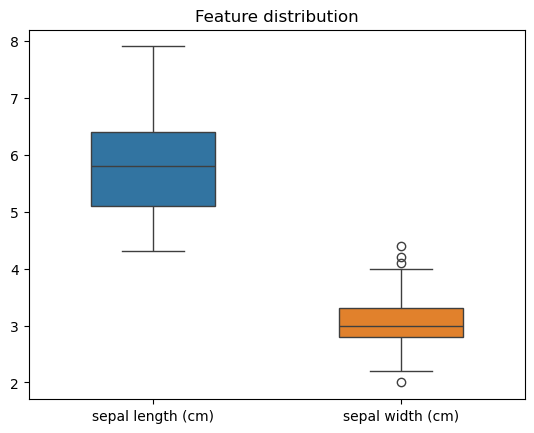

In [12]:
import seaborn as sns #For feature visualization options

selected_features = features[:,0:2]
ax = sns.boxplot(data=selected_features, width=0.5)

# YOUR CODE HERE
ax.set_xticklabels(iris.feature_names[:2])
ax.set_title("Feature distribution")
plt.show()

Let's try the violin plot as suggested 

C:\Users\Maribel ITU\AppData\Local\Temp\ipykernel_19708\2846465793.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(iris.feature_names[:2])


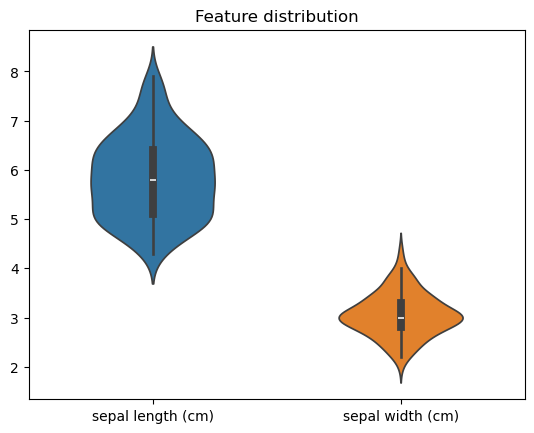

In [13]:
ax = sns.violinplot(data=selected_features, width=0.5)

# YOUR CODE HERE
ax.set_xticklabels(iris.feature_names[:2])
ax.set_title("Feature distribution")
plt.show()

We've seen in the first plot that the features values tend to be within a certain range depending on the class the instance belongs to, should we maybe look at the feature distribution for each class? 

## Feature scaling

We can see that the features are on different scales, we can transform them with the preprocessing package  

Hint: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
Hint2: Pay special attention to the `fit()` and `transform()` methods

[-1.69031455e-15 -1.84297022e-15]
[1. 1.]


C:\Users\Maribel ITU\AppData\Local\Temp\ipykernel_19708\2050508740.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(iris.feature_names[:2])


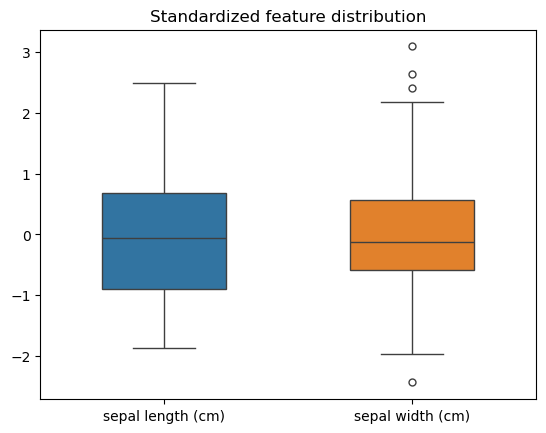

In [14]:
from sklearn import preprocessing #For preprocessing the features

#Fit scaler on our data
scaler = preprocessing.StandardScaler().fit(features)

#Apply to data itself. Later in the course, the scaler will be estimated on the training data, and then applied both to training and test data
scaled_features = scaler.transform(features)

#Verify that the features are now scaled
print(scaled_features.mean(axis=0)) # one mean per feature, small numbers close to 0 (round of error)
print(scaled_features.var(axis=0))  # one variance per feature, both equal to 1 

# Plot the feature distributions, with the scle
ax = sns.boxplot(data=scaled_features, width=0.5,fliersize=5) #we see both negative and positive values, since the mean is 0
ax.set_xticklabels(iris.feature_names[:2])
ax.set_title("Standardized feature distribution")
plt.show()

## Viewing features together

A different alternative is to look at features jointly with a pairplot.

Pairplot needs a DataFrame (pandas) where all the information about the data is stored together, so we need to create that first  

Hint: https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [15]:
import pandas as pd

iris_df = pd.DataFrame(features, columns=iris.feature_names[:2]) 
iris_df['label'] = [iris.target_names[label] for label in labels]

iris_df.head() #this displays the top rows in the dataframe in a nice format

,sepal length (cm),sepal width (cm),label
0,5.1,3.5,setosa
1,4.9,3.0,setosa
2,4.7,3.2,setosa
3,4.6,3.1,setosa
4,5.0,3.6,setosa


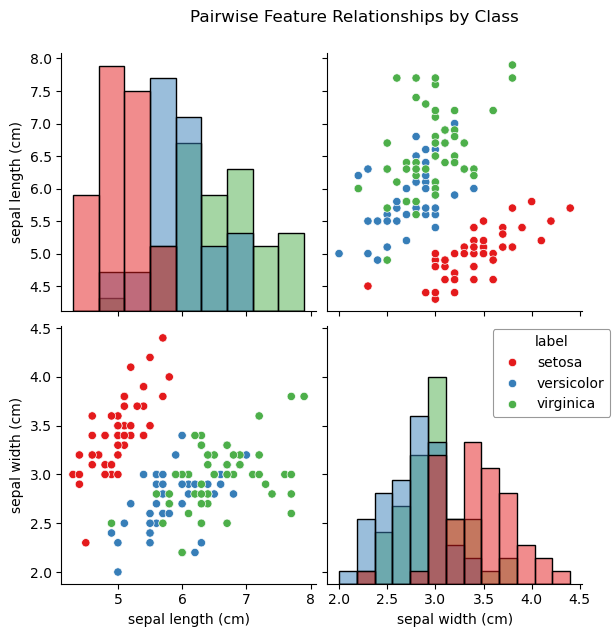

In [48]:
# Look at pairs of features
g = sns.pairplot(iris_df, hue='label', palette="Set1", height=3, diag_kind="hist")

g.fig.suptitle("Pairwise Feature Relationships by Class", y=1.05)

# Make the legend prettier
g._legend.set_bbox_to_anchor((0.86, 0.44))

g._legend.set_frame_on(True)
frame = g._legend.get_frame()
frame.set_edgecolor("gray")
frame.set_linewidth(0.8)
frame.set_facecolor("white")

plt.show()

What interesting conclusions can you draw from this plot?

It is nice to see the separation of classes in the scatterplot, and we get an idea of the overall feature distribution in the histograms, however it'd be better to see those features distributions within each class more clearly.

Text(0.5, 1.0, 'Feature distribution by label')

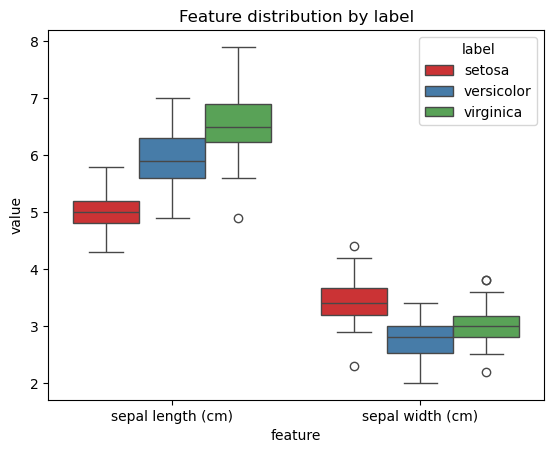

In [17]:
iris_long_df = iris_df.melt(
    id_vars="label",
    var_name="feature",
    value_name="value"
) # we moved from having one row = one instance to one row = one (instance, feature) pair. i want to do this to make my life easier when drawing the boxplot

ax = sns.boxplot(data=iris_long_df, x="feature", y="value", hue="label", palette="Set1")
ax.set_title("Feature distribution by label")